In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


# 📊 Customer Churn Analysis
## Telco Customer Dataset

**Dataset:** 7,043 customers | 21 variables  
**Tool:** Python (Pandas, Matplotlib)  
**Goal:** Identify key factors driving customer churn and provide actionable business insights.

---

In [12]:
# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Load & Explore the Dataset
Loading the CSV file and taking a first look at the data structure.

In [13]:
# Check column names and data types
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
Payment

## 2. Data Quality Check
Checking for missing values and data types across all 21 columns.
No missing values were found — the dataset is clean and ready for analysis.

In [14]:
# How many customers churned vs stayed
print(df['Churn'].value_counts())
print("\nChurn rate:")
print(round(df['Churn'].value_counts(normalize=True) * 100, 2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## 3. Churn Distribution
Analyzing the overall churn rate across all 7,043 customers.

> 💡 Key Insight: 26.54% of customers churned — meaning 1 in 4 customers 
> left the service. This is a significant business problem worth investigating.

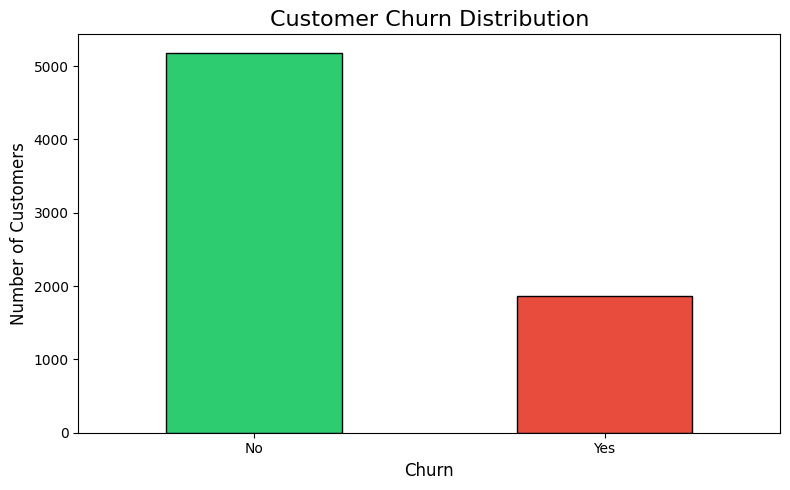

Chart saved!


In [15]:
# Plot churn distribution
colors = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    figsize=(8, 5)
)
plt.title('Customer Churn Distribution', fontsize=16)
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/churn_distribution.png')
plt.show()
print("Chart saved!")

## 4. Churn by Contract Type
Analyzing how contract length affects customer churn rate.

> 💡 Key Insight: Month-to-month contract customers showed the highest churn 
> rate — suggesting the company should incentivize customers to switch to 
> longer term contracts to improve retention.

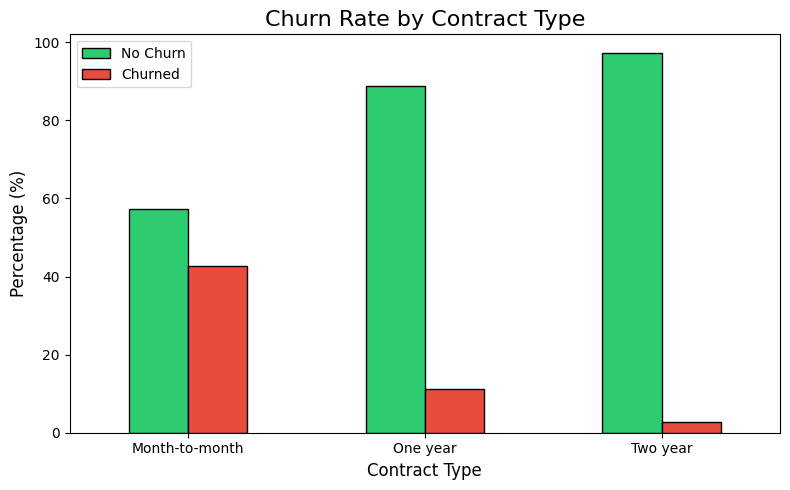

Chart saved!


In [16]:
# Churn by contract type
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

contract_churn.plot(
    kind='bar',
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    figsize=(8, 5)
)
plt.title('Churn Rate by Contract Type', fontsize=16)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churned'])
plt.tight_layout()
plt.savefig('../images/churn_by_contract.png')
plt.show()
print("Chart saved!")

## 5. Churn by Internet Service Type
Analyzing churn rates across different internet service types.

> 💡 Key Insight: Fiber optic customers had the highest churn rate despite 
> having the fastest service — suggesting dissatisfaction may be related to 
> pricing rather than service quality.

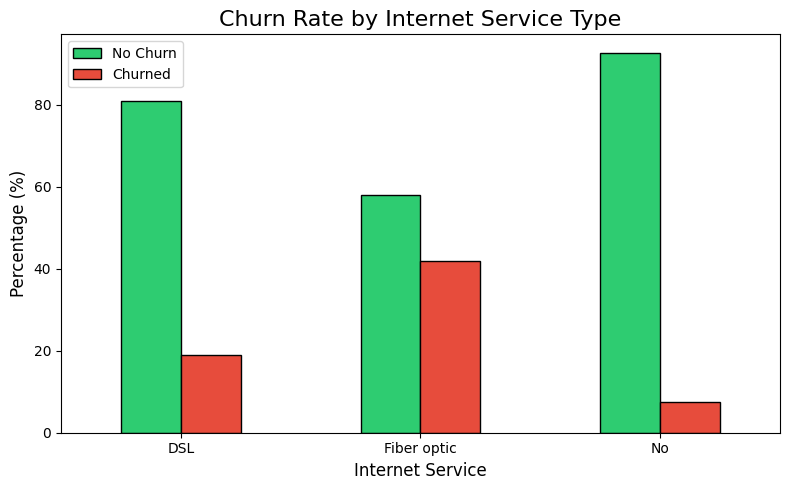

Chart saved!


In [17]:
# Churn by internet service type
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100

internet_churn.plot(
    kind='bar',
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    figsize=(8, 5)
)
plt.title('Churn Rate by Internet Service Type', fontsize=16)
plt.xlabel('Internet Service', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churned'])
plt.tight_layout()
plt.savefig('../images/churn_by_internet.png')
plt.show()
print("Chart saved!")

## 6. Churn by Customer Tenure
Analyzing how long customers stayed before churning.

> 💡 Key Insight: Customers who churned had an average tenure of only 17.98 
> months compared to 37.57 months for loyal customers — meaning the first 
> 18 months is the critical retention window for this business.

Average tenure by churn status (months):
Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64


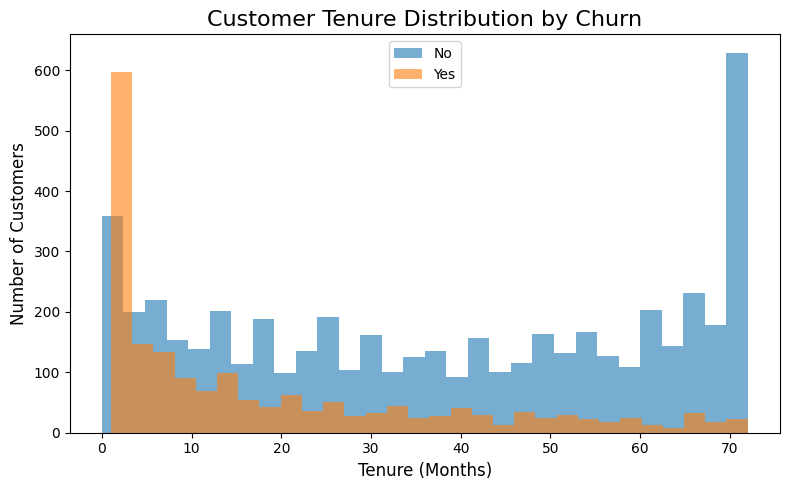

Chart saved!


In [18]:
# Average tenure by churn
tenure_churn = df.groupby('Churn')['tenure'].mean()
print("Average tenure by churn status (months):")
print(round(tenure_churn, 2))

# Plot
df.groupby('Churn')['tenure'].plot(
    kind='hist',
    bins=30,
    alpha=0.6,
    figsize=(8, 5),
    legend=True
)
plt.title('Customer Tenure Distribution by Churn', fontsize=16)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.savefig('../images/churn_by_tenure.png')
plt.show()
print("Chart saved!")

## 7. Churn by Monthly Charges
Analyzing whether higher monthly charges are linked to customer churn.

> 💡 Key Insight: Churned customers paid an average of $74.44/month compared 
> to $61.27 for loyal customers — confirming that high pricing is a major 
> driver of churn and should be addressed through targeted discount strategies.

Average monthly charges by churn status:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


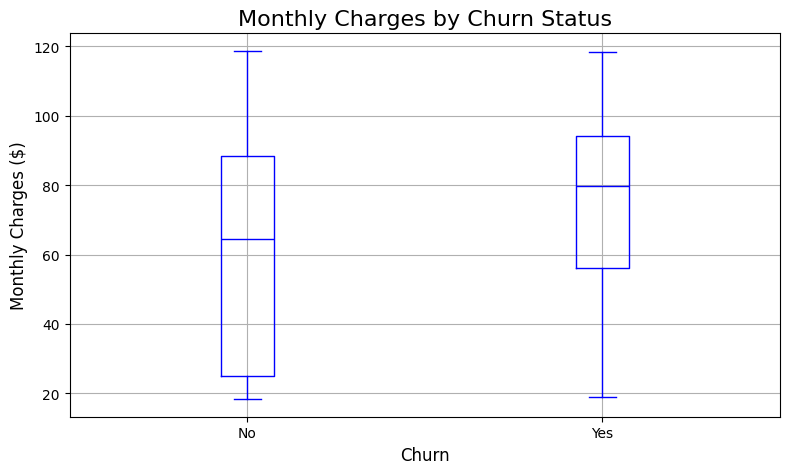

Chart saved!


In [19]:
# Average monthly charges by churn
charges_churn = df.groupby('Churn')['MonthlyCharges'].mean()
print("Average monthly charges by churn status:")
print(round(charges_churn, 2))

# Plot
df.boxplot(
    column='MonthlyCharges',
    by='Churn',
    figsize=(8, 5),
    color='blue'
)
plt.title('Monthly Charges by Churn Status', fontsize=16)
plt.suptitle('')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.tight_layout()
plt.savefig('../images/churn_by_charges.png')
plt.show()
print("Chart saved!")

## 8. Churn by Senior Citizen Status
Analyzing whether age group affects customer churn behavior.

> 💡 Key Insight: Non-senior customers showed higher churn rates than senior 
> customers — suggesting younger customers are more likely to switch providers, 
> possibly due to better price comparison habits and lower switching costs.

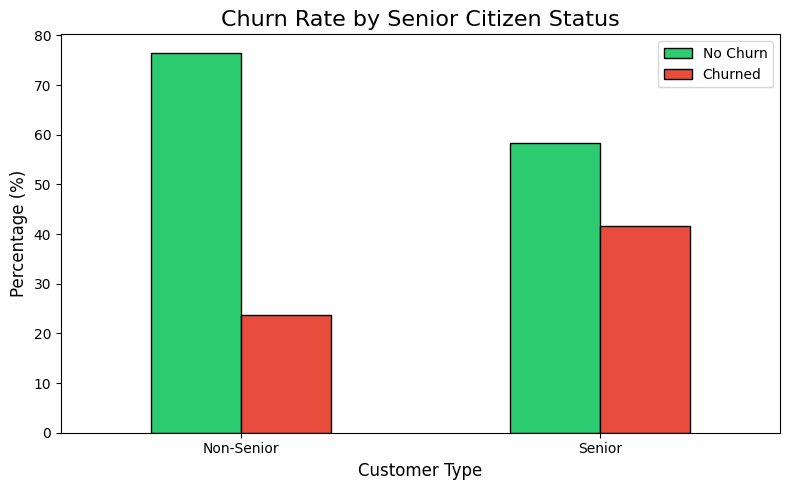

Chart saved!


In [20]:
# Churn by senior citizen status
senior_churn = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

senior_churn.index = ['Non-Senior', 'Senior']
senior_churn.plot(
    kind='bar',
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    figsize=(8, 5)
)
plt.title('Churn Rate by Senior Citizen Status', fontsize=16)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churned'])
plt.tight_layout()
plt.savefig('../images/churn_by_senior.png')
plt.show()
print("Chart saved!")

## 9. Key Insights Summary
A consolidated summary of all findings from this analysis.

### 🔑 Top Business Recommendations:
1. **Target month-to-month customers** with incentives to switch to annual contracts
2. **Review Fiber Optic pricing** — highest churn despite premium service
3. **Focus retention efforts on the first 18 months** — critical churn window
4. **Introduce loyalty discounts** for customers paying above $70/month
5. **Design retention campaigns for younger customers** who switch more frequently

In [21]:
# Final summary of key insights
print("=" * 50)
print("KEY INSIGHTS SUMMARY")
print("=" * 50)
print(f"Total Customers: {len(df):,}")
print(f"Churn Rate: 26.54%")
print(f"Avg Tenure (Churned): 17.98 months")
print(f"Avg Tenure (Loyal): 37.57 months")
print(f"Avg Monthly Charges (Churned): $74.44")
print(f"Avg Monthly Charges (Loyal): $61.27")
print(f"Highest Churn by Contract: Month-to-Month")
print(f"Highest Churn by Internet: Fiber Optic")
print(f"Highest Churn by Age Group: Non-Senior")
print("=" * 50)

KEY INSIGHTS SUMMARY
Total Customers: 7,043
Churn Rate: 26.54%
Avg Tenure (Churned): 17.98 months
Avg Tenure (Loyal): 37.57 months
Avg Monthly Charges (Churned): $74.44
Avg Monthly Charges (Loyal): $61.27
Highest Churn by Contract: Month-to-Month
Highest Churn by Internet: Fiber Optic
Highest Churn by Age Group: Non-Senior


## 10. Conclusion

This analysis of 7,043 Telco customers revealed several key drivers of churn:

| Factor | Finding |
|--------|---------|
| Overall Churn Rate | 26.54% — 1 in 4 customers left |
| Contract Type | Month-to-month contracts had highest churn |
| Internet Service | Fiber optic customers churned the most |
| Tenure | Churned customers stayed only 17.98 months on average |
| Monthly Charges | Churned customers paid $74.44 vs $61.27 for loyal customers |
| Age Group | Non-senior customers churned more than seniors |

### Tools Used
- Python 3
- Pandas — data manipulation
- Matplotlib — data visualization

### Dataset
- Source: Kaggle — Telco Customer Churn
- Size: 7,043 rows × 21 columns